In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import swin_v2_t, swin_v2_s

from PIL import Image
import numpy as np

from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

from torchvision.transforms import v2
from torchvision.transforms import InterpolationMode


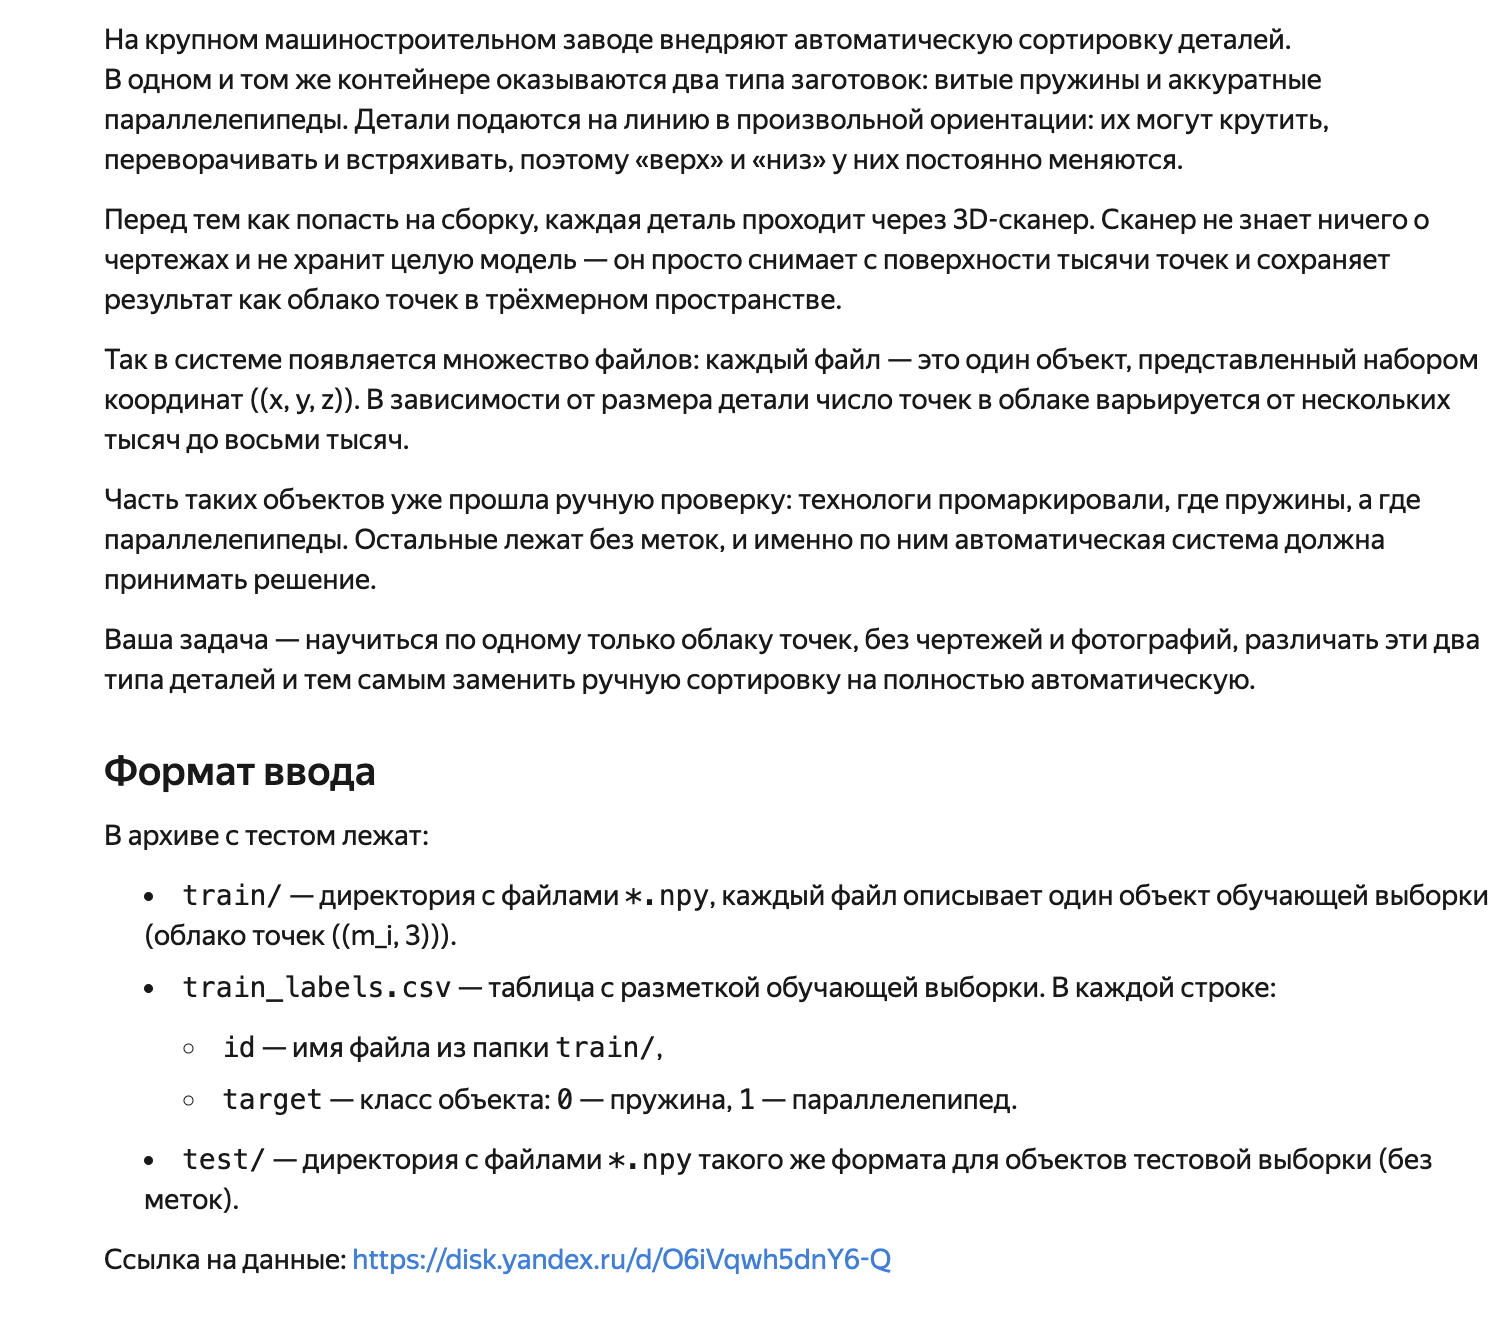

In [9]:
train = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-nuts-and-bolts/Nuts_bolts/train_labels.csv')
test = pd.read_csv('/kaggle/input/datasets/ivanpronin/dls-2026-nuts-and-bolts/Nuts_bolts/test.csv')

dataset_path = '/kaggle/input/datasets/ivanpronin/dls-2026-nuts-and-bolts/Nuts_bolts/'

In [34]:
class PointDataset:
    def __init__(self, df, data_dir):

        self.df = df

        self.data_dir = data_dir

        self.max_n = 10_000
        
        self.transforms = v2.Compose([
                    v2.ToImage(),                            
                    v2.ToDtype(torch.float32, scale=True),
                    v2.CenterCrop(size=(260, 260)),
                    v2.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),   # Изменение размера
                    v2.RandomHorizontalFlip(p=0.5),
                    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
        

    def __len__(self):
        return self.df.shape[0]

    def pad(self, points):
        padding = self.max_n - points.shape[0]
        points = np.pad(points, ((0,padding), (0,0)), mode='constant')
        return points
        
    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        
        path = self.data_dir + row['path']

        points = np.load(path)

        points = self.pad(points)

        im = points.reshape((100,100, 3))
        target = row['target']

        if self.transforms:
            im = self.transforms(im)
        else:
            return im
            
        return {'image':im, 'target':target}

In [35]:
def train_model(model, train_loader, val_loader, device='cpu'):

    train_metrics = {'Loss':[], 'F1':[], 'ROC_AUC':[]}

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4,weight_decay=1e-4)
    
    for batch_idx, batch  in enumerate(train_loader):

        im  = batch['image'].to(device)
        label = batch['target'].to(device).float()

        optimizer.zero_grad()
        
        outputs  = model(im).squeeze(1)

        loss = criterion(outputs, label)

        loss.backward()
        optimizer.step()

            
        if batch_idx % 50 == 0:
            probs = F.sigmoid(outputs).detach().cpu()
            preds = probs>0.5

            f1 = f1_score(label.detach().cpu(), preds)
            roc_auc = roc_auc_score(label.detach().cpu(), probs)
            
            train_metrics['ROC_AUC'].append(f1)
            train_metrics['F1'].append(f1)
            train_metrics['Loss'].append(loss.item())
            
            print(f"Batch: {batch_idx} | Loss: {loss.item():4f} | ROC_AUC: {roc_auc:4f} | F1: {f1:4f}")

    model.eval()
    val_metrics = {'Loss':[], 'F1':[], 'ROC_AUC':[]}
    device='cuda' 

    predictions = []
    probabilities = []
    labels = []
    for batch_idx, batch  in enumerate(val_loader):
    
        im  = batch['image'].to(device)
        label = batch['target'].to(device).float()
    
        with torch.no_grad(): 
            outputs  = model(im).squeeze(1)
    
        loss = criterion(outputs, label)
    
        probs = F.sigmoid(outputs).detach().cpu()
        preds = probs>0.5
        
        predictions.extend(preds)
        probabilities.extend(probs)
        labels.extend(label.detach().cpu())
        
        
        val_metrics['Loss'].append(loss.item())

    
    f1 = f1_score(labels, predictions)
    roc_auc = roc_auc_score(labels, probabilities)
        
    val_metrics['ROC_AUC'].append(f1)
    val_metrics['F1'].append(f1)
        
        
    return model, train_metrics, val_metrics
    

In [7]:
model = swin_v2_t(weights='IMAGENET1K_V1')
model.head = nn.Sequential(
                nn.Linear(768, 1),
)

if torch.cuda.device_count() > 1:
    print('Using Data Parallel')
    model = nn.DataParallel(model)

model.to('cuda')

print('Model loaded')

Using Data Parallel
Model loaded


In [10]:
train, val = train_test_split(train, test_size=0.2, shuffle=True)

In [36]:
data_dir = '/kaggle/input/datasets/ivanpronin/dls-2026-nuts-and-bolts/Nuts_bolts/'
train_dataset = PointDataset(train, data_dir)
val_dataset = PointDataset(val, data_dir)


train_loader = DataLoader(train_dataset, batch_size = 50,shuffle = True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size = 25,shuffle = False, num_workers=4)

In [37]:
epochs = 20

metrics = {'Loss':[],'F1':[], 'ROC_AUC':[]} 
for epoch in range(epochs):
    model, train_metrics, val_metrics = train_model(model, train_loader, val_loader, device='cuda')
    #model,  val_metrics = validate_model(model, val_loader, device='cuda')

    train_loss = np.mean(train_metrics['Loss'])
    train_f1 = np.mean(train_metrics['F1'])
    train_roc_auc = np.mean(train_metrics['ROC_AUC'])
    

    val_loss = np.mean(val_metrics['Loss'])
    val_f1 = np.mean(val_metrics['F1'])
    val_roc_auc = np.mean(train_metrics['ROC_AUC'])
    

    metrics['Loss'].append(val_loss)
    metrics['F1'].append(val_f1)
    metrics['ROC_AUC'].append(val_roc_auc)
    
    
    print(f"\n Epoch: {epoch} | Train Loss: {train_loss:4f} | Train ROC-AUC: {train_roc_auc:4f} | Val F1: {train_f1:4f} | \n"
        F"Val Loss: {val_loss:4f} | Val ROC-AUC: {val_roc_auc:4f} | Val F1: {val_f1:4f}  \n")
    

Batch: 0 | Loss: 0.107980 | ROC_AUC: 0.993600 | F1: 0.980392

 Epoch: 0 | Train Loss: 0.107980 | Train ROC-AUC: 0.980392 | Val F1: 0.980392 | 
Val Loss: 0.220090 | Val ROC-AUC: 0.980392 | Val F1: 0.942308  

Batch: 0 | Loss: 0.101178 | ROC_AUC: 0.980800 | F1: 0.980392

 Epoch: 1 | Train Loss: 0.101178 | Train ROC-AUC: 0.980392 | Val F1: 0.980392 | 
Val Loss: 0.179911 | Val ROC-AUC: 0.980392 | Val F1: 0.943396  

Batch: 0 | Loss: 0.092702 | ROC_AUC: 0.991319 | F1: 0.984615

 Epoch: 2 | Train Loss: 0.092702 | Train ROC-AUC: 0.984615 | Val F1: 0.984615 | 
Val Loss: 0.278113 | Val ROC-AUC: 0.984615 | Val F1: 0.924528  

Batch: 0 | Loss: 0.026677 | ROC_AUC: 1.000000 | F1: 1.000000

 Epoch: 3 | Train Loss: 0.026677 | Train ROC-AUC: 1.000000 | Val F1: 1.000000 | 
Val Loss: 0.281708 | Val ROC-AUC: 1.000000 | Val F1: 0.912281  

Batch: 0 | Loss: 0.133422 | ROC_AUC: 0.985600 | F1: 0.961538

 Epoch: 4 | Train Loss: 0.133422 | Train ROC-AUC: 0.961538 | Val F1: 0.961538 | 
Val Loss: 0.296397 | Val 

In [38]:
class TestPointDataset:
    def __init__(self, df, data_dir):

        self.df = df

        self.data_dir = data_dir

        self.max_n = 10_000
        
        self.transforms = v2.Compose([
                    v2.ToImage(),                            
                    v2.ToDtype(torch.float32, scale=True),
                    v2.CenterCrop(size=(260, 260)),
                    v2.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),   # Изменение размера
                    v2.RandomHorizontalFlip(p=0.5),
                    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
        

    def __len__(self):
        return self.df.shape[0]

    def pad(self, points):
        padding = self.max_n - points.shape[0]
        points = np.pad(points, ((0,padding), (0,0)), mode='constant')
        return points
        
    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        
        path = self.data_dir + row['path']

        points = np.load(path)

        points = self.pad(points)

        im = points.reshape((100,100, 3))

        if self.transforms:
            im = self.transforms(im)
        else:
            return im
            
        return {'image':im}

In [39]:
data_dir = '/kaggle/input/datasets/ivanpronin/dls-2026-nuts-and-bolts/Nuts_bolts/'
test_dataset = TestPointDataset(test, data_dir)

test_loader = DataLoader(test_dataset, batch_size = 25,shuffle = False, num_workers=4)

In [40]:
from tqdm import tqdm
all_ids = []
all_labels = []
device='cuda'

model.eval()
for batch in tqdm(test_loader):

    image = batch['image'].to(device)

    with torch.no_grad():
        outputs = model(image)

    preds = (F.sigmoid(outputs>0) > 0.5).detach().cpu().numpy().astype(int)

    all_labels.extend(preds)

100%|██████████| 20/20 [00:02<00:00,  7.69it/s]


In [41]:
sub = pd.DataFrame(all_labels, columns=['target'])
sub.target = sub

In [42]:
sub

,target
0,1
1,0
2,1
3,0
4,1
...,...
495,0
496,0
497,0
498,0


In [43]:
sub.to_csv('test_sub_well.csv', index=False)